
# UTKFace Dataset – Exploratory Data Analysis

Analyse exploratoire complète du jeu de données UTKFace afin de préparer la modélisation multi-tâches (âge, genre, ethnicité) et sa conversion TensorFlow Lite.



## Objectifs de l'étude
1. Utiliser le dataset UTKFace déjà présent dans le repo (pas de téléchargement Kaggle dans ce notebook).
2. Construire une table d'observations à partir des noms de fichiers (âge/genre/ethnicité) et dériver des features utiles (décennies, buckets d'âges, etc.).
3. Explorer les distributions d'âge, de genre et d'ethnicité à l'aide de visualisations commentées.
4. Vérifier l'équilibre des classes et mesurer les corrélations simples pour anticiper les biais de modélisation.
5. Afficher des exemples visuels pour relier les statistiques aux visages réels.


In [1]:
# Imports principaux pour la manipulation de données, la visualisation et l'affichage d'images
from __future__ import annotations
from pathlib import Path
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Configuration graphique homogène pour l'ensemble du notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Détection robuste du dossier racine (gère le cas où cwd est supprimé)
def find_base_dir() -> Path:
    candidates = []
    try:
        candidates.append(Path.cwd())
    except FileNotFoundError:
        pass
    pwd = os.environ.get("PWD")
    if pwd:
        candidates.append(Path(pwd))
    if "__file__" in globals():
        try:
            candidates.append(Path(__file__).resolve().parent)
        except Exception:
            pass
    candidates.append(Path("/home/carld/face-analysis-deep-learning"))
    # Uniq en conservant l'ordre
    uniq = []
    seen = set()
    for c in candidates:
        if c and c not in seen:
            uniq.append(c)
            seen.add(c)
    for base in uniq:
        if (base / "data").exists():
            return base
        for parent in base.parents:
            if (parent / "data").exists():
                return parent
    return uniq[0] if uniq else Path(".")

BASE_DIR = find_base_dir()
DATA_DIR = BASE_DIR / "data"
CANDIDATE_IMAGE_DIRS = [
    DATA_DIR / "utkface_aligned_cropped" / "UTKFace",
    DATA_DIR / "utkface_aligned_cropped" / "crop_part1",
    DATA_DIR / "UTKFace",
    DATA_DIR / "crop_part1",
]
GENDER_MAP = {0: "Male", 1: "Female"}
ETHNICITY_MAP = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}


## Chargement des données (local)
Le dataset UTKFace est déjà versionné dans le repo (`data/`). Ce notebook ne télécharge rien depuis Kaggle : il réutilise les images présentes localement. Si le dossier est manquant, placez UTKFace dans `data/UTKFace` ou `data/utkface_aligned_cropped/UTKFace`.


In [2]:
import os

# Sélectionne le premier dossier images existant parmi les chemins connus
candidate_dirs = [p for p in CANDIDATE_IMAGE_DIRS if p.exists()]
if not candidate_dirs:
    found = []
    for root, dirs, files in os.walk(DATA_DIR):
        if any(f.lower().endswith((".jpg", ".jpeg", ".png", ".chip.jpg")) for f in files):
            found.append(Path(root))
    candidate_dirs = found

if not candidate_dirs:
    raise FileNotFoundError("UTKFace introuvable. Placez les images dans data/UTKFace ou data/utkface_aligned_cropped/UTKFace.")

IMAGES_DIR = candidate_dirs[0]
print(f"✔ Dossier images détecté : {IMAGES_DIR}")

✔ Dossier images détecté : /home/carld/face-analysis-deep-learning/data/utkface_aligned_cropped/UTKFace



## Construction du DataFrame
Extraction des labels (âge, genre, ethnicité) à partir des noms de fichiers. Ajout de variables dérivées utiles pour l'analyse (décennie, bucket d'âge, etc.).


In [3]:
# Parsing des images UTKFace déjà présentes dans le repo → DataFrame
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".chip.jpg")
image_paths = sorted({p for ext in IMAGE_EXTS for p in IMAGES_DIR.rglob(f"*{ext}")})
print(f"Nb images trouvées : {len(image_paths):,}")

if len(image_paths) == 0:
    raise FileNotFoundError(f"Aucune image trouvée dans {IMAGES_DIR}")

records = []
for path in tqdm(image_paths, desc="Parsing filenames"):
    base = path.name
    lower = base.lower()
    for ext in (".chip.jpg", ".jpg", ".jpeg", ".png"):
        if lower.endswith(ext):
            base = base[: -len(ext)]
            break
    parts = base.split("_")
    if len(parts) < 3:
        continue
    try:
        age = int(parts[0])
        gender_id = int(parts[1])
        ethnicity_id = int(parts[2])
    except ValueError:
        continue
    records.append({
        "age": age,
        "gender_id": gender_id,
        "gender": GENDER_MAP.get(gender_id, "Unknown"),
        "ethnicity_id": ethnicity_id,
        "ethnicity": ETHNICITY_MAP.get(ethnicity_id, "Unknown"),
        "filepath": str(path),
    })

df = pd.DataFrame(records)

# Normalisation et features dérivées
if not df.empty:
    df["age"] = df["age"].clip(lower=0)
    df["gender"] = pd.Categorical(df["gender"], categories=list(GENDER_MAP.values()))
    df["ethnicity"] = pd.Categorical(df["ethnicity"], categories=list(ETHNICITY_MAP.values()))
    df["age_decade"] = (df["age"] // 10) * 10
    age_bins = [-1, 1, 4, 12, 19, 29, 39, 49, 59, 69, 79, 89, 120]
    age_labels = ["0-1", "2-4", "5-12", "13-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90+"]
    df["age_bucket"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)
    print("\n" + "="*60)
    print("✔ DATASET PRÊT !")
    print("="*60)
    print(df.head(10))
    print(f"\nTotal d'images exploitables : {len(df):,}")
else:
    raise ValueError("DataFrame vide : aucun fichier n'a pu être parsé correctement.")

Nb images trouvées : 23,708


Parsing filenames:   0%|          | 0/23708 [00:00<?, ?it/s]


✔ DATASET PRÊT !
   age  gender_id  gender  ethnicity_id ethnicity  \
0  100          0    Male             0     White   
1  100          0    Male             0     White   
2  100          1  Female             0     White   
3  100          1  Female             0     White   
4  100          1  Female             0     White   
5  100          1  Female             0     White   
6  100          1  Female             0     White   
7  100          1  Female             0     White   
8  100          1  Female             2     Asian   
9  100          1  Female             2     Asian   

                                            filepath  age_decade age_bucket  
0  /home/carld/face-analysis-deep-learning/data/u...         100        90+  
1  /home/carld/face-analysis-deep-learning/data/u...         100        90+  
2  /home/carld/face-analysis-deep-learning/data/u...         100        90+  
3  /home/carld/face-analysis-deep-learning/data/u...         100        90+  
4  /home

### Vue d'ensemble du dataset

In [4]:

# Résumé rapide pour prendre connaissance des ordres de grandeur et répartitions globales
dataset_summary = pd.Series({
    "Nombre d'images": len(df),
    "Âge minimum": int(df["age"].min()),
    "Âge maximum": int(df["age"].max()),
    "Âge moyen": round(df["age"].mean(), 2),
    "Âge médian": float(df["age"].median()),
    "Écart-type âge": round(df["age"].std(), 2),
    "Genres": df["gender"].value_counts().to_dict(),
    "Ethnicités": df["ethnicity"].value_counts().to_dict(),
})
display(dataset_summary.to_frame(name="Valeur"))


,Valeur
Nombre d'images,23705
Âge minimum,1
Âge maximum,116
Âge moyen,33.3
Âge médian,29.0
Écart-type âge,19.89
Genres,"{'Male': 12391, 'Female': 11314}"
Ethnicités,"{'White': 10078, 'Black': 4526, 'Indian': 3975..."


In [5]:
import pandas as pd
from IPython.display import display

# Suppose dataset_summary existe déjà
df_summary = dataset_summary.to_frame(name="Valeur")

# Styler : augmente la taille de police, padding, et la largeur du tableau
styler = (
    df_summary.style
    .set_table_attributes('style="width:80%; border-collapse:collapse;"')
    .set_properties(**{
        'font-size': '18pt',   # taille du texte
        'padding': '10px',     # espacement des cellules
        'text-align': 'left'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '20pt'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('vertical-align', 'middle')]}
    ])
)

display(styler)

,Valeur
Nombre d'images,23705
Âge minimum,1
Âge maximum,116
Âge moyen,33.300000
Âge médian,29.000000
Écart-type âge,19.890000
Genres,"{'Male': 12391, 'Female': 11314}"
Ethnicités,"{'White': 10078, 'Black': 4526, 'Indian': 3975, 'Asian': 3434, 'Others': 1692}"


## Analyse de l'âge

In [6]:

# Statistiques descriptives détaillées incluant plusieurs quantiles
age_stats = df["age"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
display(age_stats.to_frame().rename(columns={"age": "Statistique"}))


,Statistique
count,23705.000000
mean,33.300907
std,19.885708
min,1.000000
25%,23.000000
50%,29.000000
75%,45.000000
90%,61.000000
95%,72.000000
max,116.000000


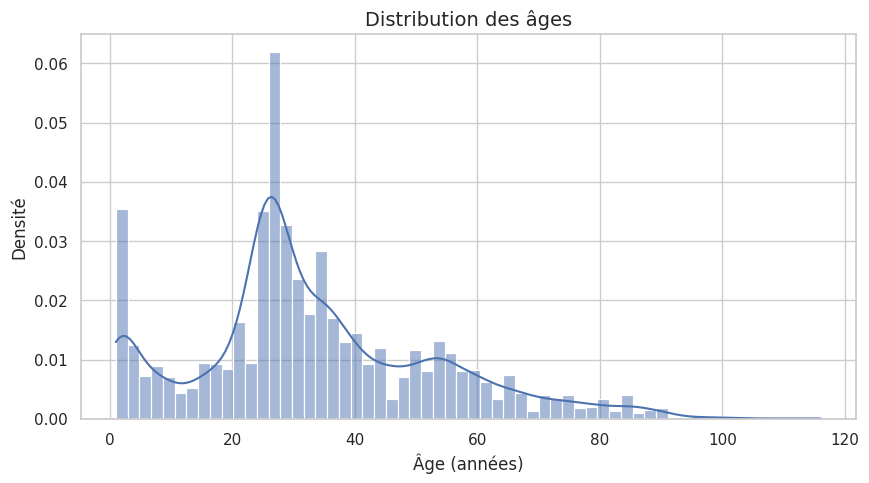

In [7]:

# Histogramme + KDE pour visualiser la distribution continue des âges
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df, x="age", bins=60, kde=True, stat="density", color="#4C72B0", ax=ax)
ax.set(title="Distribution des âges", xlabel="Âge (années)", ylabel="Densité")
plt.show()


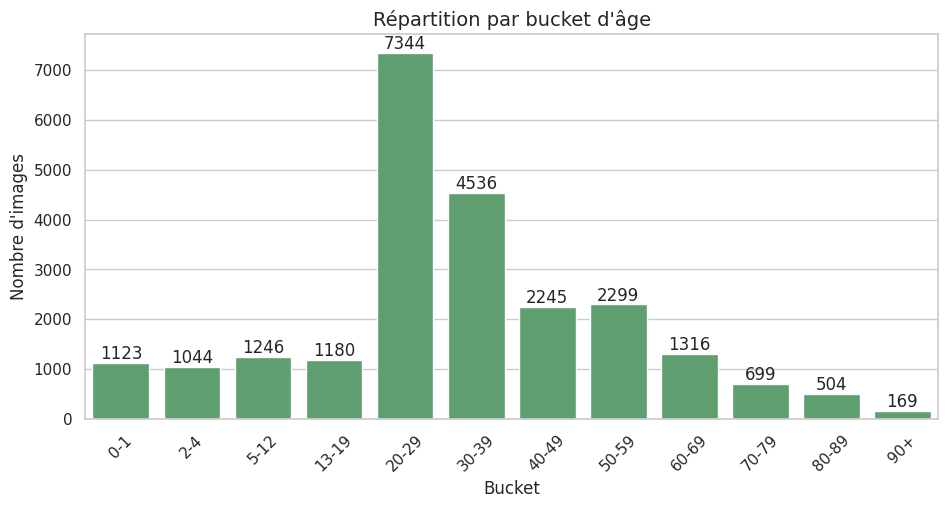

In [8]:

# Répartition discrète par bucket d'âge pour identifier les tranches dominantes
fig, ax = plt.subplots(figsize=(11, 5))
bucket_counts = df["age_bucket"].value_counts().reindex(age_labels)
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=ax, color="#55A868")
ax.set(title="Répartition par bucket d'âge", xlabel="Bucket", ylabel="Nombre d'images")
ax.bar_label(ax.containers[0], fmt="%d")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_49934/3227456593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="gender", y="age", inner="quart", palette="Set2", ax=ax)


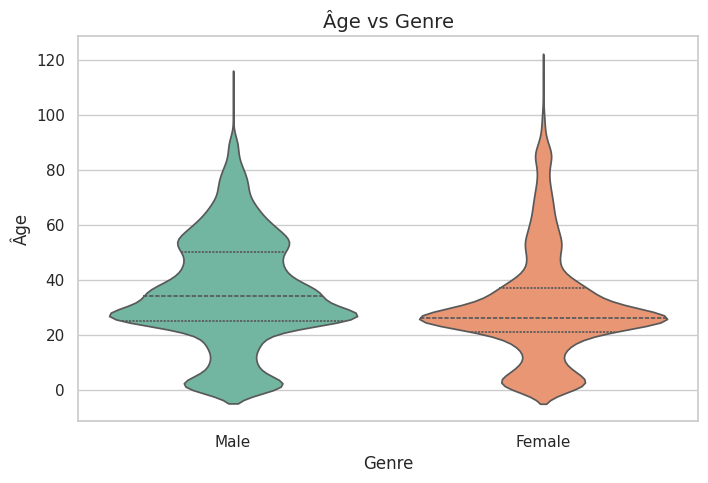

In [9]:

# Violin plot pour comparer les distributions d'âge selon le genre
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="gender", y="age", inner="quart", palette="Set2", ax=ax)
ax.set(title="Âge vs Genre", xlabel="Genre", ylabel="Âge")
plt.show()


/tmp/ipykernel_49934/2462687416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="ethnicity", y="age", palette="Set3", ax=ax)


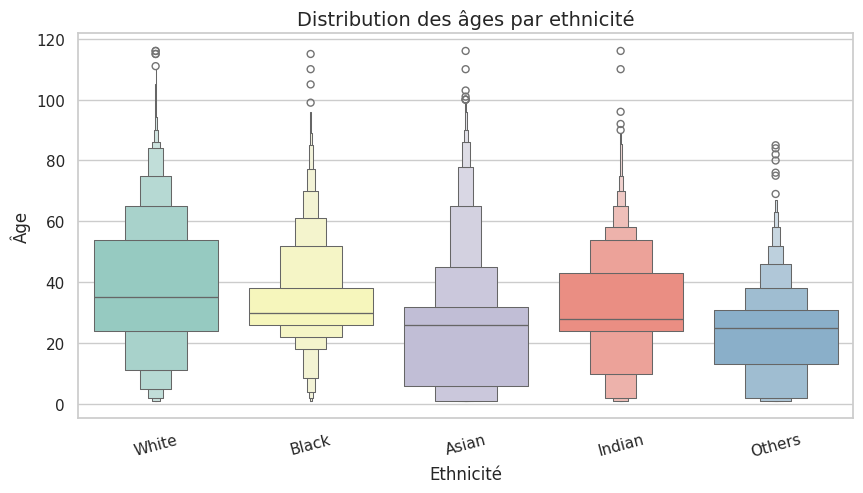

In [10]:

# Boxenplot pour étudier la distribution d'âge par ethnicité (plus robuste aux outliers)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxenplot(data=df, x="ethnicity", y="age", palette="Set3", ax=ax)
ax.set(title="Distribution des âges par ethnicité", xlabel="Ethnicité", ylabel="Âge")
plt.xticks(rotation=15)
plt.show()


## Analyse du genre

/tmp/ipykernel_49934/4229296555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="Set2", ax=ax)


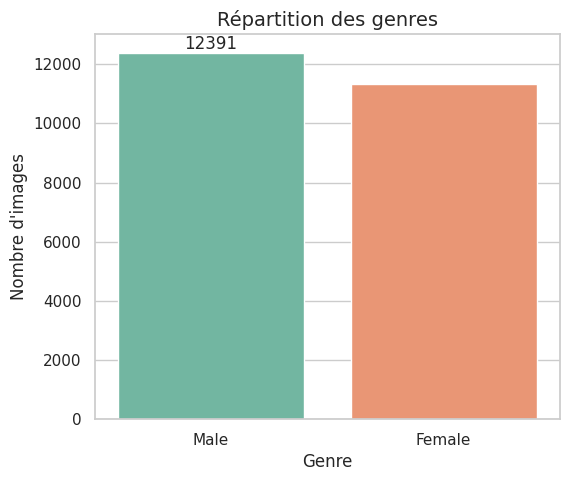

,Genre,Proportion (%)
0,Male,52.27
1,Female,47.73


In [11]:

# Comptage absolu et proportions pour vérifier l'équilibre hommes/femmes
gender_counts = df["gender"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="Set2", ax=ax)
ax.set(title="Répartition des genres", xlabel="Genre", ylabel="Nombre d'images")
ax.bar_label(ax.containers[0], fmt="%d")
plt.show()

pd.DataFrame({
    "Genre": gender_counts.index,
    "Proportion (%)": (gender_counts / len(df) * 100).round(2).values,
})


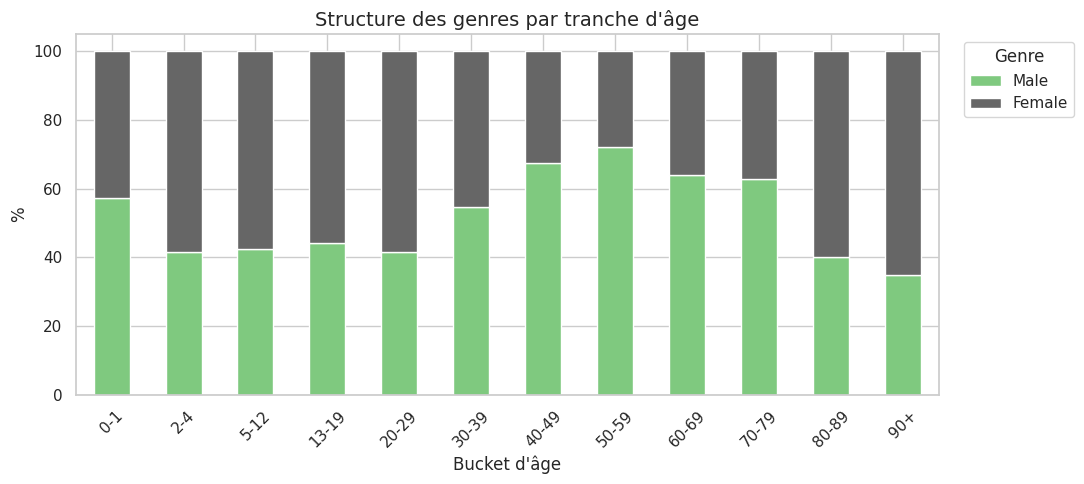

In [12]:

# Crosstab empilée pour visualiser la variation du genre en fonction du bucket d'âge
age_gender = pd.crosstab(df["age_bucket"], df["gender"], normalize="index") * 100
age_gender = age_gender.reindex(age_labels)
fig, ax = plt.subplots(figsize=(11, 5))
age_gender.plot(kind="bar", stacked=True, ax=ax, colormap="Accent")
ax.set(title="Structure des genres par tranche d'âge", xlabel="Bucket d'âge", ylabel="%")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Analyse de l'ethnicité

/tmp/ipykernel_49934/2592465796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eth_counts.index, y=eth_counts.values, palette="tab10", ax=ax)


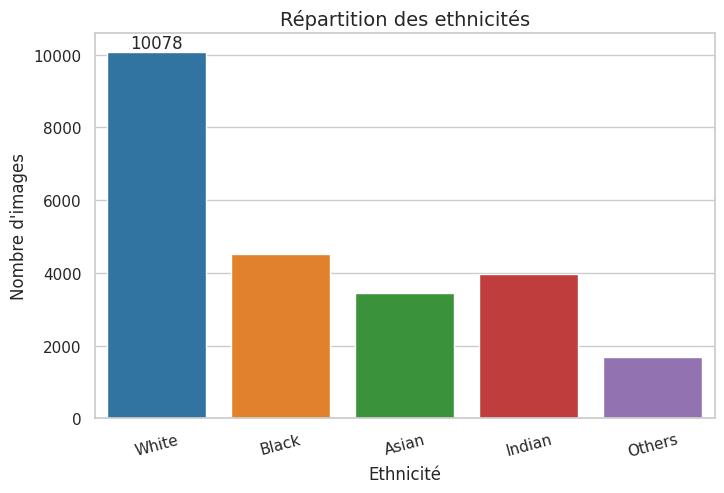

,Ethnicité,Proportion (%)
0,White,42.51
1,Black,19.09
2,Asian,14.49
3,Indian,16.77
4,Others,7.14


In [13]:

# Répartition globale des ethnicités pour anticiper les déséquilibres de classe
eth_counts = df["ethnicity"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=eth_counts.index, y=eth_counts.values, palette="tab10", ax=ax)
ax.set(title="Répartition des ethnicités", xlabel="Ethnicité", ylabel="Nombre d'images")
ax.bar_label(ax.containers[0], fmt="%d", rotation=0)
plt.xticks(rotation=15)
plt.show()

pd.DataFrame({
    "Ethnicité": eth_counts.index,
    "Proportion (%)": (eth_counts / len(df) * 100).round(2).values,
})


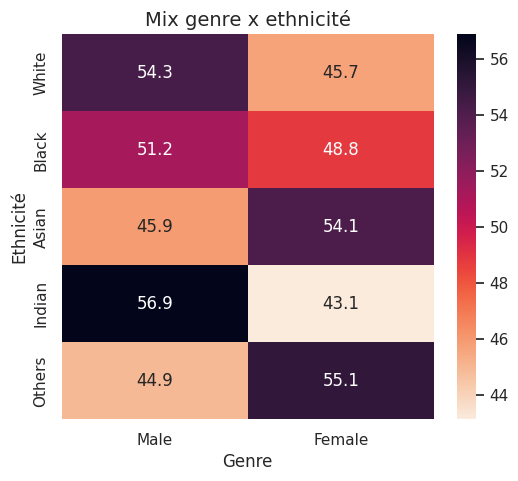

In [14]:

# Heatmap du mix genre/ethnicité pour repérer les biais potentiels par sous-population
eth_gender = pd.crosstab(df["ethnicity"], df["gender"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(eth_gender, annot=True, fmt=".1f", cmap="rocket_r", ax=ax)
ax.set(title="Mix genre x ethnicité", xlabel="Genre", ylabel="Ethnicité")
plt.show()


/tmp/ipykernel_49934/2614312432.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eth_age = df.groupby("ethnicity")["age"].agg(["count", "mean", "median", "std"]).round(2)


,count,mean,median,std
ethnicity,,,,
White,10078,37.98,35.0,21.94
Black,4526,33.86,30.0,14.83
Asian,3434,25.87,26.0,20.41
Indian,3975,31.53,28.0,16.98
Others,1692,23.17,25.0,14.49


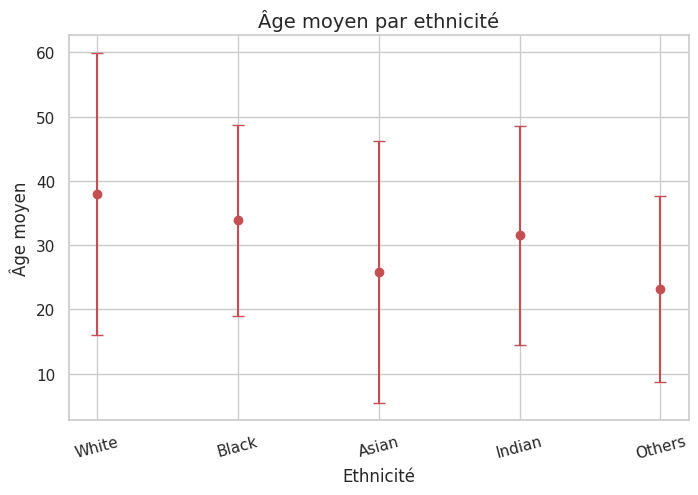

In [15]:

# Moyenne, médiane et dispersion de l'âge par ethnicité pour comprendre les différences démographiques
eth_age = df.groupby("ethnicity")["age"].agg(["count", "mean", "median", "std"]).round(2)
display(eth_age)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(eth_age.index, eth_age["mean"], yerr=eth_age["std"], fmt="o", capsize=4, color="#C44E52")
ax.set(title="Âge moyen par ethnicité", xlabel="Ethnicité", ylabel="Âge moyen")
plt.xticks(rotation=15)
plt.show()


## Exemples visuels

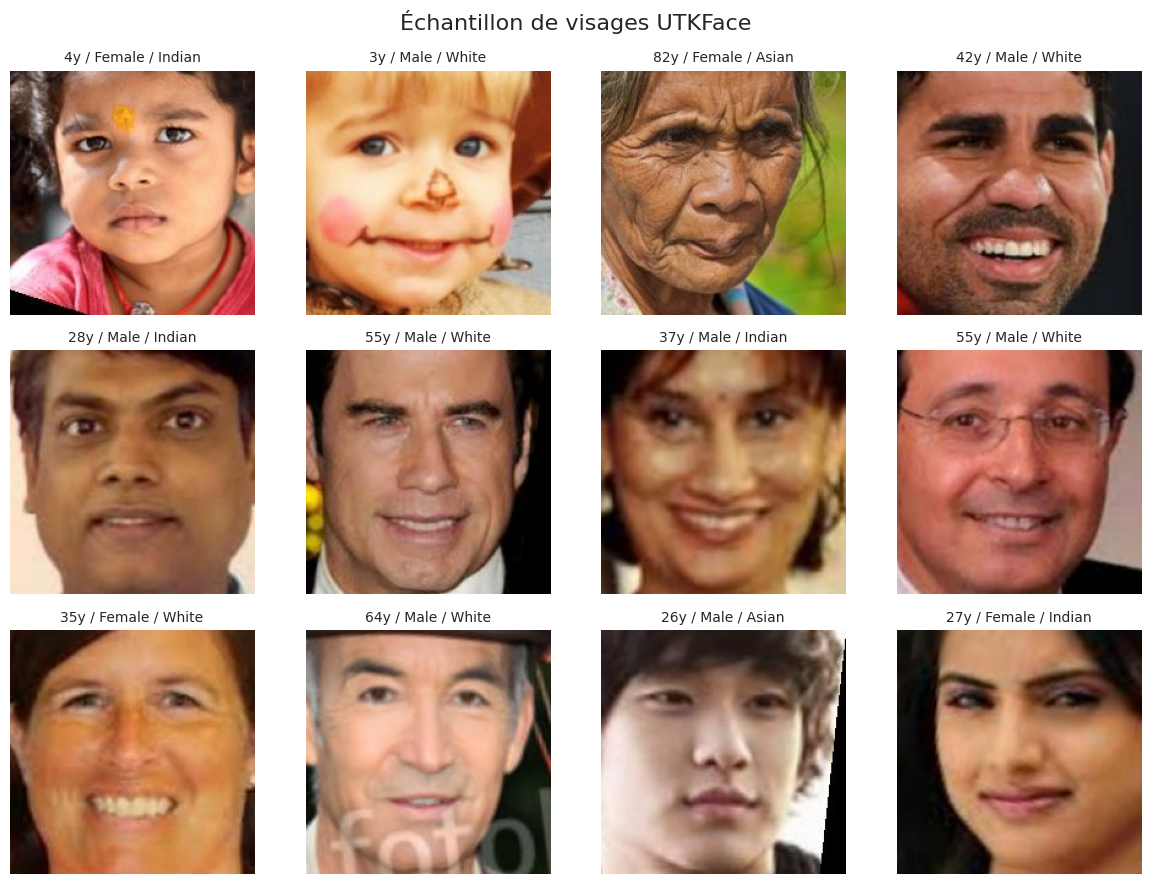

In [16]:

# Fonction utilitaire pour afficher une grille d'exemples aléatoires représentatifs
from math import ceil

rng = np.random.default_rng(42)

def show_face_grid(sample_df: pd.DataFrame, n_images: int = 12, cols: int = 4):
    # Échantillonne n_images lignes puis affiche les images correspondantes avec les métadonnées clés
    sample = sample_df.sample(n_images, random_state=42).reset_index(drop=True)
    rows = ceil(n_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['age']}y / {row['gender']} / {row['ethnicity']}", fontsize=10)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle("Échantillon de visages UTKFace", fontsize=16)
    plt.tight_layout()

show_face_grid(df, n_images=12, cols=4)
